# 12 · Earnings quality: the accrual anomaly

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/valuein/valuein/blob/main/examples/notebooks/12_earnings_quality.ipynb)

**What you will learn**

- What accruals are, and why earnings backed by cash are considered higher quality.
- How to compute the Sloan accrual ratio across the S&P 500 from annual reported facts, as known
  on a date.
- How to test whether low-accrual companies outperformed, point in time and net of costs.

**Plan required:** none (free sample tier).

In [1]:
%pip install -q valuein-sdk matplotlib

Note: you may need to restart the kernel to use updated packages.


## 1. The idea

Net income = operating cash flow + accruals. Accruals (receivables booked before cash arrives,
inventory build-ups, provisions) are estimates, and estimates reverse. Richard Sloan (1996)
found that companies whose earnings were mostly accruals tended to have lower future earnings
and returns. The usual measure:

**accrual ratio = (net income - operating cash flow) / average total assets**

Positive: earnings exceed cash generated. Negative: cash exceeds reported earnings.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from valuein_sdk import ValueinClient, backtest

client = ValueinClient()
AS_OF = "2025-06-30"

annual = client.run_query(f"""
    WITH fy AS (
        SELECT entity_id, period_end, standard_concept, numeric_value
        FROM fact
        WHERE standard_concept IN ('NetIncome', 'OperatingCashFlow', 'TotalAssets')
          AND fiscal_period = 'FY'
          AND accepted_at <= TIMESTAMP '{AS_OF}'
          AND (period_span_days BETWEEN 350 AND 380 OR period_start IS NULL)
        QUALIFY ROW_NUMBER() OVER (
            PARTITION BY entity_id, standard_concept, period_end ORDER BY accepted_at DESC, priority DESC) = 1
    ),
    wide AS (
        SELECT entity_id, period_end,
               max(CASE WHEN standard_concept = 'NetIncome' THEN numeric_value END)         AS net_income,
               max(CASE WHEN standard_concept = 'OperatingCashFlow' THEN numeric_value END) AS ocf,
               max(CASE WHEN standard_concept = 'TotalAssets' THEN numeric_value END)       AS assets
        FROM fy GROUP BY entity_id, period_end
    )
    SELECT entity_id AS cik, period_end, net_income, ocf, assets,
           lag(assets) OVER (PARTITION BY entity_id ORDER BY period_end) AS prior_assets
    FROM wide
    QUALIFY ROW_NUMBER() OVER (PARTITION BY entity_id ORDER BY period_end DESC) = 1
""")
annual["accrual_ratio"] = (annual["net_income"] - annual["ocf"]) / ((annual["assets"] + annual["prior_assets"]) / 2)

members = client.universe(dates=[AS_OF])[["cik", "ticker", "name", "sector"]]
accruals = members.merge(annual, on="cik", how="inner").dropna(subset=["accrual_ratio"])
print(f"S&P 500 members on {AS_OF} with an accrual ratio: {len(accruals)} of {len(members)}")
accruals["accrual_ratio"].describe().round(3)


Upgrade access:
  Register (free)  → Benchmark: full history for every S&P 500 constituent
  Add API token    → Full US equities universe + complete history

Get your token: https://valuein.biz
  client = ValueinClient()


S&P 500 members on 2025-06-30 with an accrual ratio: 416 of 499


count    416.000
mean      -0.038
std        0.088
min       -1.417
25%       -0.057
50%       -0.035
75%       -0.015
max        0.539
Name: accrual_ratio, dtype: float64

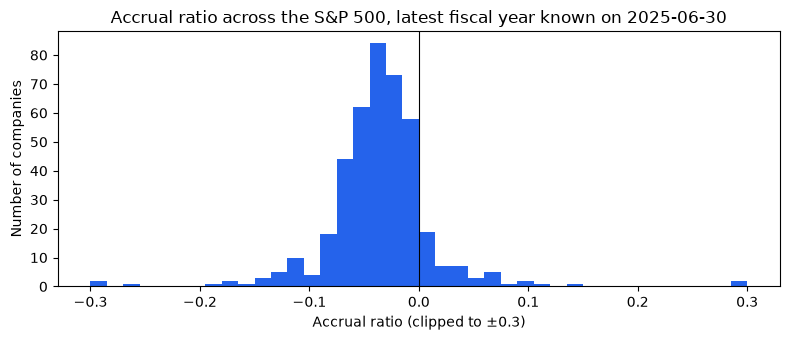

In [3]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(accruals["accrual_ratio"].clip(-0.3, 0.3), bins=40, color="#2563eb")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Accrual ratio (clipped to ±0.3)")
ax.set_ylabel("Number of companies")
ax.set_title(f"Accrual ratio across the S&P 500, latest fiscal year known on {AS_OF}")
plt.tight_layout()
plt.show()

## 2. Who relies most on accruals?

Sector matters: banks and insurers have cash flows that do not map to this measure, and capital-
heavy industries carry large depreciation, so compare a company with its own sector before
reading anything into a high value.

In [4]:
accruals["sector_median"] = accruals.groupby("sector")["accrual_ratio"].transform("median")
accruals["vs_sector"] = accruals["accrual_ratio"] - accruals["sector_median"]
columns = ["ticker", "name", "sector", "period_end", "accrual_ratio", "vs_sector"]
accruals.sort_values("vs_sector", ascending=False)[columns].head(10).round({"accrual_ratio": 3, "vs_sector": 3})

,ticker,name,sector,period_end,accrual_ratio,vs_sector
405,SMCI,"Super Micro Computer, Inc.",Information Technology,2024-06-30,0.539,0.585
313,MPWR,"MONOLITHIC POWER SYSTEMS, INC.",Information Technology,2024-12-31,0.330,0.376
74,CARR,CARRIER GLOBAL Corp,Industrials,2024-12-31,0.144,0.178
83,CEG,Constellation Energy Corp,Utilities,2024-12-31,0.120,0.155
340,NVDA,NVIDIA CORP,Information Technology,2025-01-26,0.099,0.145
440,TRMB,TRIMBLE INC.,Health Care,2025-01-03,0.102,0.135
407,SNPS,SYNOPSYS INC,Information Technology,2024-10-31,0.073,0.119
366,PHM,PULTEGROUP INC/MI/,Industrials,2024-12-31,0.084,0.118
133,DHI,HORTON D R INC /DE/,Industrials,2024-09-30,0.075,0.109
309,MO,"ALTRIA GROUP, INC.",Consumer Staples,2024-12-31,0.068,0.097


## 3. Did low accruals pay?

Valuein also publishes a Sloan accrual ratio in the `ratio` table (`sloan_accruals`). Its exact
denominator may differ from the one above, so check that the two agree in ranking before you
use it:

In [5]:
published = client.signal_panel(client.universe(dates=[AS_OF]), ratios=["sloan_accruals"], include_price=False)
both = accruals.merge(published[["cik", "sloan_accruals"]], on="cik").dropna()
print(f"rank correlation, our ratio vs sloan_accruals: "
      f"{both['accrual_ratio'].rank().corr(both['sloan_accruals'].rank()):.2f} over {len(both)} companies")

rank correlation, our ratio vs sloan_accruals: 0.95 over 416 companies


Now the backtest, exactly as in notebook 04: quarterly signal dates, the value known on each
date, entry at the next month-end close, 10 bps costs. `ascending=True` because a *low* accrual
ratio is the attractive end.

In [6]:
def monthly_forward_returns(client: ValueinClient, panel: pd.DataFrame) -> pd.DataFrame:
    """Append forward returns built from month-end closes (see notebook 04 for the reasoning)."""
    bars = client.run_query("""
        SELECT entity_id AS cik, price_date, total_return_index AS tri
        FROM stock_price
        WHERE observation = 'monthly' AND total_return_index IS NOT NULL
        QUALIFY ROW_NUMBER() OVER (PARTITION BY entity_id, price_date ORDER BY security_id) = 1
    """)
    bars["price_date"] = pd.to_datetime(bars["price_date"])
    bars = bars.sort_values("price_date")
    dates = sorted(panel["rebalance_date"].unique())
    out = panel.merge(pd.DataFrame({"rebalance_date": dates[:-1], "next_date": dates[1:]}), on="rebalance_date")
    out = pd.merge_asof(out.sort_values("rebalance_date"),
                        bars.rename(columns={"price_date": "entry_price_date", "tri": "entry_price"}),
                        by="cik", left_on="rebalance_date", right_on="entry_price_date",
                        direction="forward", allow_exact_matches=False)
    out = pd.merge_asof(out.sort_values("next_date"),
                        bars.rename(columns={"price_date": "exit_price_date", "tri": "exit_price"}),
                        by="cik", left_on="next_date", right_on="exit_price_date",
                        direction="forward", allow_exact_matches=False)
    last = bars.groupby("cik").tail(1).rename(columns={"price_date": "last_date", "tri": "last_price"})
    out = out.merge(last, on="cik", how="left")
    stopped = out["exit_price"].isna() & (out["last_date"] > out["entry_price_date"])
    out["truncated"] = stopped
    out.loc[stopped, "exit_price"] = out.loc[stopped, "last_price"]
    out["entry_stale"] = out["entry_price_date"].isna() | (
        (out["entry_price_date"] - out["rebalance_date"]).dt.days > 35)
    out["tradable"] = ~out["entry_stale"] & out["exit_price"].notna() & (out["entry_price"] > 0)
    out["forward_return"] = np.where(out["tradable"], out["exit_price"] / out["entry_price"] - 1, np.nan)
    return out.drop(columns=["next_date", "last_date", "last_price"]).reset_index(drop=True)


dates = [f"{y}-{m:02d}-24" for y in range(2022, 2027) for m in (3, 6, 9, 12) if f"{y}-{m:02d}-24" <= "2026-06-24"]
panel = client.signal_panel(client.universe(dates=dates), ratios=["sloan_accruals"], include_price=False)
with_returns = monthly_forward_returns(client, panel)
with_returns.attrs["execution_lag"] = 4  # weekdays from the 24th to the month-end fill (notebook 04)
result = backtest(with_returns, signal="sloan_accruals", ascending=True, quantiles=5, cost_bps=10.0)
print(result.summary())

Backtest — 'sloan_accruals' | long/short | top/bottom 5 quantiles | equal-weighted
  execution lag 4 trading day(s), costs 10.0 bps per unit traded, 3.9918 rebalances/yr

NET OF COSTS
  Periods             17 @ 3.9918/yr
  Total return        +1.46%
  Annualized return   +0.34%
  Annualized vol      5.96%
  Sharpe              0.09
  Sortino             0.13
  Max drawdown        -12.60%
  Calmar              0.03
  Hit rate            47.1%
  Best / worst        +6.66% / -5.67%
  Skew / ex-kurtosis  0.12 / 0.57
  VaR / CVaR (95%)    -4.66% / -5.67%

  gross annualized   +0.70%   (cost drag 0.36%)
  mean IC            +0.0157   IC-IR 0.22
  mean turnover      45.1% one-way per rebalance
  universe return    +2.60% per period (equal-weight, same universe)

EXCLUSIONS
  dates used 17 of 17
  names scored 403/date (81% of universe had a usable signal)
  positions truncated by delisting: 11
  rows untradable at entry (stale/absent bar): 0


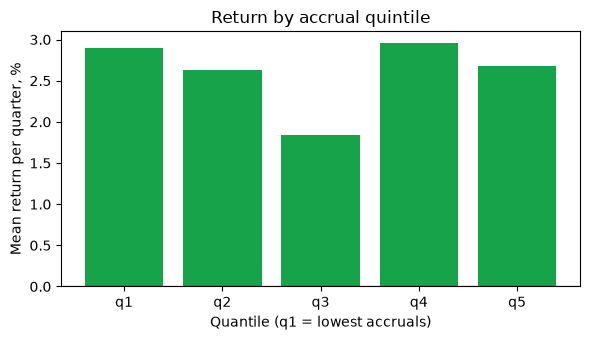

In [7]:
q = result.quantile_summary() * 100
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(q.index, q.values, color="#16a34a")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Quantile (q1 = lowest accruals)")
ax.set_ylabel("Mean return per quarter, %")
ax.set_title("Return by accrual quintile")
plt.tight_layout()
plt.show()

A few years of one large-cap index is a small sample: read the IC and the ordering of the
buckets, not only the headline return. A longer history (Benchmark back to 1993) and a broader
universe (Pro and Institutional) are the natural next test.

In [8]:
client.close()

## Next steps

- **[13 · Sector comparison](13_sector_comparison.ipynb)**: decompose return on equity by sector.
- **[16 · Filing delay](16_filing_delay.ipynb)**: another quality signal, from filing dates alone.